# Tema : Modelos ARIMA
![](src/img/logo_utb.png){width=40%} 
![](src/img/logo_etd.png){width=40%}
- **Profesor:**
- **Fernando Salcedo Mejía, Eco Msc.**
- Programa de Ciencias de Datos | Escuela de transformación digital.
- 2026-1

## Ejercicio 1. Pronostico del PIB de Colombia.

- Usando los datos del Banco Mundial, estime un modelo ARIMA válido acorde a la teoría entre 1960-2024. Finalmente, realice el pronostico del PIB de Colombia para los próximos 5 años.



In [5]:
# Librerias necesarias

# Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb

# Modelos de tiempo
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# Estadisticos
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.metrics import r2_score


# Descargar los datos del Banco Mundial

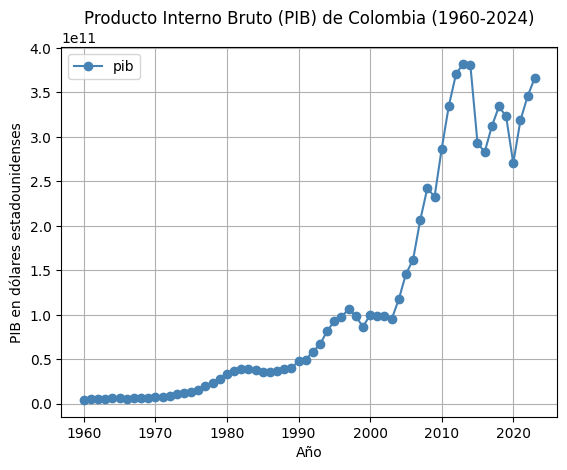

In [12]:
data = wb.data.DataFrame(series='NY.GDP.MKTP.CD', economy='COL', time=range(1960, 2024), columns='series').reset_index()
data.columns = ['year', 'pib']
data['year'] = data['year'].str.replace('YR', '').astype(int)
data.index = data.year

data.plot(x='year', y='pib', kind='line', marker='o', color='steelblue')
plt.title('Producto Interno Bruto (PIB) de Colombia (1960-2024)')
plt.xlabel('Año')
plt.ylabel('PIB en dólares estadounidenses')
plt.grid()
plt.show()